<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic3.1-Classification_Basics/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Classification Basics

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic3.1-Classification_Basics_Problems.zip) <archives/Topic3.1-Classification_Basics_Problems.zip>` — the notebook and
`flammability_campaignA.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Classification Basics </3-classification/Topic3.1-Classification_Basics>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::



## Setup

A process-safety laboratory is mapping out when a methane–air mixture will ignite. Each
test fills a spherical vessel with a known mixture of **methane**, **added nitrogen** and
**air**, fires a spark, and records whether a flame propagated. You have 800 such tests,
all run at 25 °C and 1 atm.

Every mixture is described by two numbers you control:

- `fuel_vol_pct` — the methane content, in volume percent
- `n2_added_vol_pct` — the nitrogen added on top of what the air already contains

The rest of the vessel is air, so `o2_vol_pct` follows from the other two: air is 20.95%
oxygen, and the air fraction is whatever is left over. It is in the file because it is what
a gas analyser actually reports, but it is not independent information.

Three things can stop a mixture from burning, and you will have met all three in a process
safety course:

- there is too little fuel — the mixture is **lean**
- there is too much fuel, so there is not enough oxygen to go round — the mixture is **rich**
- so much nitrogen has been added that the oxygen is diluted below the level any flame can
  propagate at, whatever the fuel concentration — the mixture is **inerted**

This set is about measuring where those boundaries are and how well a classifier can be
made to respect them. **No numerical limit values are given to you** — published values
exist for methane and you will compare against them at the end of Part C, but everything
before that comes out of the data.

Each test carries two labels:

| Column | Meaning |
|---|---|
| `ignited` | 1 if a flame propagated, 0 if not |
| `regime` | `flammable` if it ignited; otherwise which of the three conditions above was binding — `lean`, `rich` or `inerted` |

The two agree by construction: a test that ignites is recorded `flammable`, and a test that
does not is recorded by the reason it did not. So `regime` is `ignited` with the failures
itemized, and neither tells you anything the other hides.

The **flammability parameters** behind this data are real published measurements
([Zlochower and Green, *J. Loss Prev. Process Ind.* **22**, 499–505,
2009](https://doi.org/10.1016/j.jlp.2009.03.006)). What is simulated is the campaign
itself: which mixtures were tested, and the outcome of each test. Real limit determinations
are not sharp — close to a limit, nominally identical mixtures ignite some of the time and
not others — so the outcome of each test near a boundary is drawn rather than decided. A
few percent of these 800 tests sit in that uncertain band.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix
from sklearn.model_selection import StratifiedKFold
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/flammability_campaignA.csv')

fuel = df['fuel_vol_pct'].values        # vol % methane
n2 = df['n2_added_vol_pct'].values      # vol % nitrogen added on top of the air
o2 = df['o2_vol_pct'].values            # vol % oxygen, = 20.95/100 * (100 - fuel - n2)
y = df['ignited'].values                # 1 = flame propagated, 0 = did not

print(f"{len(df)} tests, all at {df['temperature_C'].iloc[0]:.0f} C")
print(f"columns: {list(df.columns)}")
print(f"fuel  spans {fuel.min():.2f} to {fuel.max():.2f} vol%")
print(f"added N2 spans {n2.min():.2f} to {n2.max():.2f} vol%")

800 tests, all at 25 C
columns: ['test_id', 'temperature_C', 'fuel_vol_pct', 'n2_added_vol_pct', 'o2_vol_pct', 'ignited', 'regime']
fuel  spans 0.07 to 19.99 vol%
added N2 spans 0.01 to 49.92 vol%


Here is where the campaign looked, with the outcomes left off — putting the outcomes on
this plot is Part B task 1.

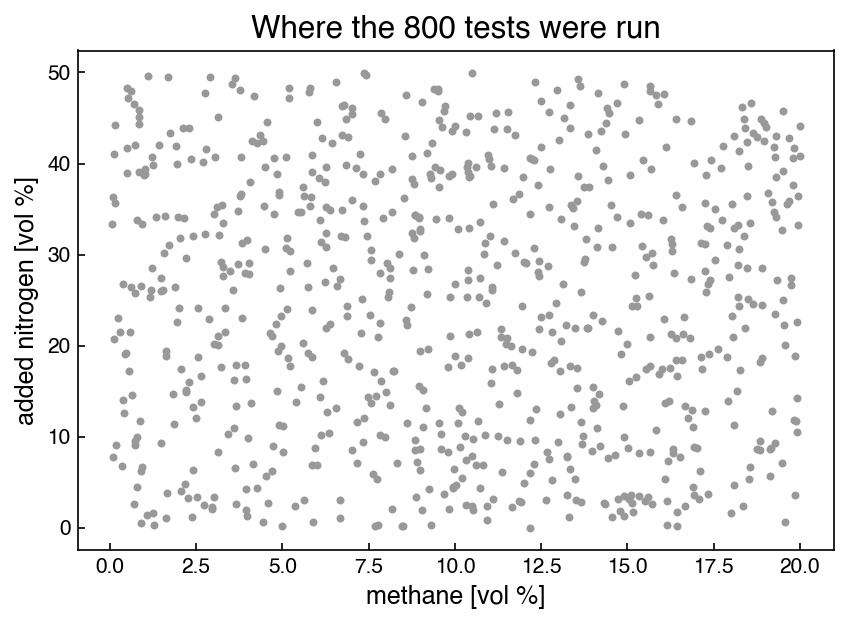

In [2]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(fuel, n2, s=8, c='0.6')
ax.set_xlabel('methane [vol %]')
ax.set_ylabel('added nitrogen [vol %]')
ax.set_title('Where the 800 tests were run');

Run this once. It defines the `check` helper used after each Part A answer. It will
not run inside the book — use the downloaded notebook.

In [ ]:
# Run this once. It defines `check`, used after each Part A answer below.
import hashlib

_EXPECTED = {
    'q1': (5, ['5f0f3cbe19c1', 'bcf31beea8f8', 'cf243bd18f64', '48ca1eb9ff7a', 'd5a97bac95e3', '7fa32ce32b20', 'a94516eecc7b']),
    'q2': (4, ['afcba4cd7b8e', '25d379d33393', '77ee4da84b54', '094d7911ca11', '86cba77344bf', 'f9c58eeee75a', 'd7ffc17fa9f9', 'fdf6b4e1b98f', 'a9d60c811299', '15aa0af9fcbc', '84d8f5437444']),
    'q3': (5, ['f73c6671ee41', '08946eae18a9', 'f265a9071014', '5dd14fd4961a', '6217a22b7dba', '2818cedd8b6d', 'cd04c4567b3c', 'a449962402b5', 'c449a4737a06', 'bf2aa1f6bcd5', '0f0c8c00ae42']),
}

def check(qid, value):
    """Compare an answer against a stored digest. Practice only -- nothing is recorded."""
    places, digests = _EXPECTED[qid]
    if value is Ellipsis:
        print(f"{qid}: not answered yet")
        return
    got = hashlib.sha256(f"{float(value):.{places}f}".encode()).hexdigest()[:12]
    print(f"{qid}: {'correct' if got in digests else 'not the expected value'}")

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each. Each asks you to assign a single number to a named
variable. Run the check cell after each one; there is no limit on attempts.

A1 counts how often the hazard actually occurs, A2 scores the alarm rule the plant
currently uses, and A3 asks how good fuel concentration is as a warning signal on its own.

### A1. How often does the hazard occur? (10 pts)

:::{exercise}
:label: pr-cls-hazard-rate

Report the fraction of the 800 tests that ignited.

Assign it to `frac_flammable`.
:::

In [ ]:
# YOUR CODE HERE
frac_flammable = ...

In [ ]:
check("q1", frac_flammable)

### A2. Score the alarm rule the plant already uses (10 pts)

:::{exercise}
:label: pr-cls-threshold-f1

The plant currently runs a single alarm: **declare the mixture flammable when
`fuel_vol_pct` is above 5.0**. Nothing else is measured.

Build that rule's predictions, score them against `ignited` with the chapter's
`acc_prec_recall`, and combine precision and recall into the F1 score

$$F_1 = \frac{2 \, p \, r}{p + r}$$

Assign the F1 score to `f1_threshold`.

You will need `acc_prec_recall` from the chapter; it is reproduced here so the notebook
runs on its own.
:::

In [ ]:
def acc_prec_recall(y_model, y_actual):
    TP = np.sum(np.logical_and(y_model == y_actual, y_model == 1))
    TN = np.sum(np.logical_and(y_model == y_actual, y_model == 0))
    FP = np.sum(np.logical_and(y_model != y_actual, y_model == 1))
    FN = np.sum(np.logical_and(y_model != y_actual, y_model == 0))
    acc = (TP + TN) / (TP + TN + FP + FN)
    if TP == 0:
        prec, recall = 0, 0
    else:
        prec = TP / (TP + FP)
        recall = TP / (TP + FN)
    return acc, prec, recall

# YOUR CODE HERE
f1_threshold = ...

In [ ]:
check("q2", f1_threshold)

### A3. How good a warning signal is fuel concentration? (10 pts)

::::{exercise}
:label: pr-cls-auc-onesided

Forget the fixed threshold and treat `fuel_vol_pct` itself as a continuous score: the
higher it is, the more dangerous the mixture is supposed to be.

Build the ROC curve for that score with `roc_curve` from `sklearn.metrics`, then report the
**area under it**. `roc_curve` returns the false-positive and true-positive rates but not
the area, so integrate it yourself with `np.trapezoid`:

```
fpr, tpr, thresholds = roc_curve(y, score)
area = np.trapezoid(tpr, fpr)
```

Assign the area to `auc_fuel`.

:::{note}
`np.trapezoid` is the NumPy 2.0 name. On older NumPy it is `np.trapz`, with the same
signature.
:::
::::

In [ ]:
# YOUR CODE HERE
auc_fuel = ...

In [ ]:
check("q3", auc_fuel)

---

## Part B — Visualization (35 pts)

Part A returned three numbers about the campaign. This part draws them.

::::{exercise}
:label: pr-cls-envelope-shape

**1. Where the hazard lives.** Scatter the campaign in the (`fuel_vol_pct`,
`n2_added_vol_pct`) plane, colored by `ignited`, with a legend. Beside it, plot a bar chart
of the four `regime` counts.

Report the **imbalance ratio**, non-flammable to flammable, as a single number. Then split
the ignited tests by added nitrogen — those below 10 vol% and those above 30 vol% — and
report the range of `fuel_vol_pct` each group spans.

In **one or two sentences**: say what those two ranges tell you about the shape of the
region, and why no single cut on `fuel_vol_pct` can describe it.

**2. What the score is actually worth.** Take the median `fuel_vol_pct` among the tests
that ignited, call it $m$, and build a second score that measures distance from it:

```
score_two_sided = -np.abs(fuel - m)
```

Plot the ROC curve for `fuel` (from A3) and the ROC curve for `score_two_sided` on the same
axes, with the chance diagonal, and report both areas.

In **two sentences**: say what the second score knows that the first does not, given that
both are built from the same single column.

**3. What the alarm rule costs.** Build the 2×2 confusion matrix for A2's rule
(`fuel_vol_pct > 5.0`) against `ignited` using `confusion_matrix` from `sklearn.metrics`,
and display it as a labelled heatmap. Separately, build the 4×4 confusion matrix of
`regime` against the same rule's prediction, treating the rule as predicting `flammable` or
`not flammable`, so you can see which regimes the false alarms come from.

Report the number of **false positives** and the number of **false negatives**.

In **one or two sentences**: say which of the two is the safety failure here, and which
regime supplies most of the false alarms.
::::

In [ ]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(7, 4))

---

## Part C — Open Ended (35 pts)

Part B showed that the flammable region is closed on more than one side, and that the
plant's one-sided alarm pays for its recall with 410 false alarms. This part builds a
better detector out of the same kind of parts — threshold conditions — by adding one side
at a time and measuring what each one buys.

You are not fitting a model here. Every rule below is a boolean expression, and you tune it
by searching a grid.

::::{exercise}
:label: pr-cls-operating-point

**1. Close the band.** Replace the one-sided alarm with a two-sided window: declare the
mixture flammable when `lo < fuel_vol_pct < hi`. Search `lo` over 4.0 to 7.0 and `hi` over
8.0 to 18.0, both in steps of 0.1, and keep the pair with the best F1 score against
`ignited`.

Report the best `lo`, `hi` and F1, along with the accuracy, precision, recall, false-alarm
count and missed-ignition count at that setting.

In **one sentence**: say how much of A2's problem the upper edge alone fixed.

**2. Add the third side.** Part B's scatter shows the band closing off at high added
nitrogen, and the Setup says why: below some oxygen level nothing propagates. Add a third
condition, `o2_vol_pct > c`, and search `c` over 9.0 to 14.0 in steps of 0.1 alongside `lo`
and `hi`.

Report the best rule and its F1, and the change in F1 and in the false-alarm count against
task 1.

Then check that the improvement is real rather than an artifact of tuning and scoring on
the same 800 rows. Using `StratifiedKFold(n_splits=5, shuffle=True, random_state=0)`,
**re-tune the rule on each training fold** and score it on the held-out fold. Report the
five fold scores and their mean, and compare to the number you got by tuning on everything.

In **two sentences**: say what the oxygen cut added, and what the gap between the two
numbers tells you.

**3. Choose an operating point.** A process-safety review will not accept a detector that
misses ignitions. Impose a floor: **recall ≥ 0.98** on the flammable class.

Among all `(lo, hi, c)` on your grid that meet it, report how many qualify, and for the one
with the highest precision report the cuts, the precision, the recall and the false-alarm
count. Compare that false-alarm count to A2's 410.

Then compare your three cuts to the published values for methane at 25 °C: a lower limit of
**5.0 vol %**, an upper limit of **15.8 vol %**, and a limiting oxygen concentration of
**11.1 vol % O₂** ([Zlochower and Green,
2009](https://doi.org/10.1016/j.jlp.2009.03.006), Table 1, 120-L chamber).

In **two sentences**: say what you give up to meet the recall floor, and name one thing
about how this campaign was run that limits how precisely you could ever locate these
boundaries.
::::

In [ ]:
# YOUR CODE HERE